# Lab Instructions

Choose your own adventure! In this lab, you will select a dataset, identify the target feature, and determine what relationships are present between the target and the other features in the data.

The dataset should have at least 5 features plus the target and at least a few hundred rows.  If the original dataset has more than 5 features, you may select the 5 that seem most interesting for this project. The subject can be anything you choose.  

For your lab submission, describe the dataset and the features - including all of the values of the features - and identify the target feature.  Then make visualizations to show the relationship of each feature to the target.  Which feature(s) seem most related?  Which features don't seem to influence the value of the target?  Draw at least one big picture conclusion about your data from the visualizations you've created.


# Dataset Overview

For this lab, I went with the Students Performance in Exams dataset from Kaggle. It has info on 1,000 students, including their background, study habits, and test scores. The dataset mixes both categorical and numerical features, so it’s pretty easy to explore how different student characteristics relate to their performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')

In [2]:
df = pd.read_csv('StudentsPerformance.csv')

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
df.dtypes

gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

# Selected Features

The dataset has more than five features, so I picked the five that seemed the most interesting for this project:

1. Gender - male or female

2. Race/Ethnicity - groups A through E

3. Parental Level of Education – high school, associate’s, bachelor’s, master’s, etc.

4. Lunch Type - standard or free/reduced

5. Test Preparation Course - completed or none

These features all have clear categories, which makes them easy to compare against the target variable.

# Target Feature

The target feature I chose is the Math Score. It’s a numerical value from 0 to 100 and basically shows how well each student did on the math section of the exam.

# Visualizations

# 1. Math Score By Gender 

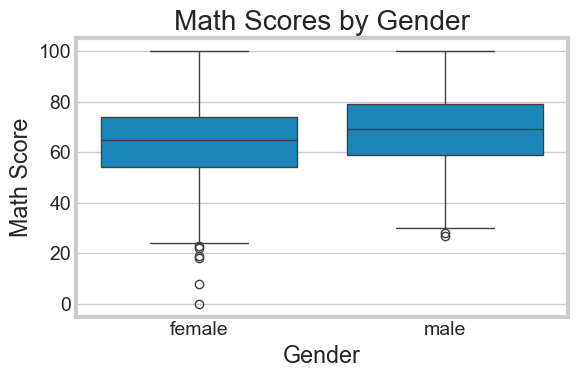

In [13]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="gender", y="math score")
plt.title("Math Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Math Score")
plt.tight_layout()
plt.show()

The math scores for males and females look pretty close overall. There are small differences, but nothing major, so gender doesn’t seem to have a big impact on math performance in this dataset.

# 2. Math Score By Lunch Type 

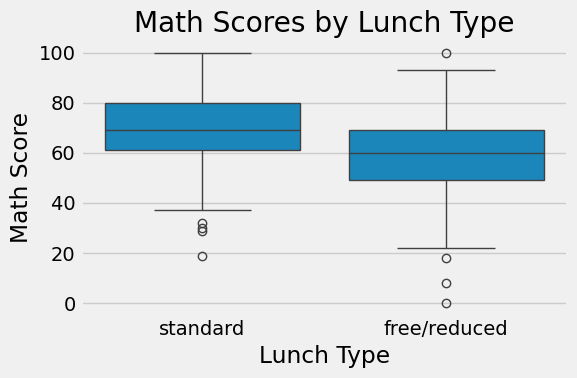

In [7]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="lunch", y="math score")
plt.title("Math Scores by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Math Score")
plt.tight_layout()
plt.show()

Looks like students with a standard lunch usually score higher in math than those with free/reduced lunch. The difference is pretty clear, so lunch type might actually have an impact on how well they do.

# 3. Math Score By Test Preparation 

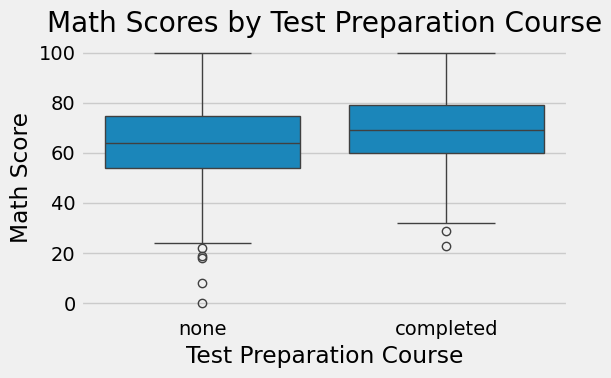

In [8]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="test preparation course", y="math score")
plt.title("Math Scores by Test Preparation Course")
plt.xlabel("Test Preparation Course")
plt.ylabel("Math Score")
plt.tight_layout()
plt.show()

Students who finished the test prep course scored noticeably higher on average. It’s one of the clearest relationships in the whole dataset, the prep course really seems to help boost math scores.

# 4. Average Math Score By Parental Education 

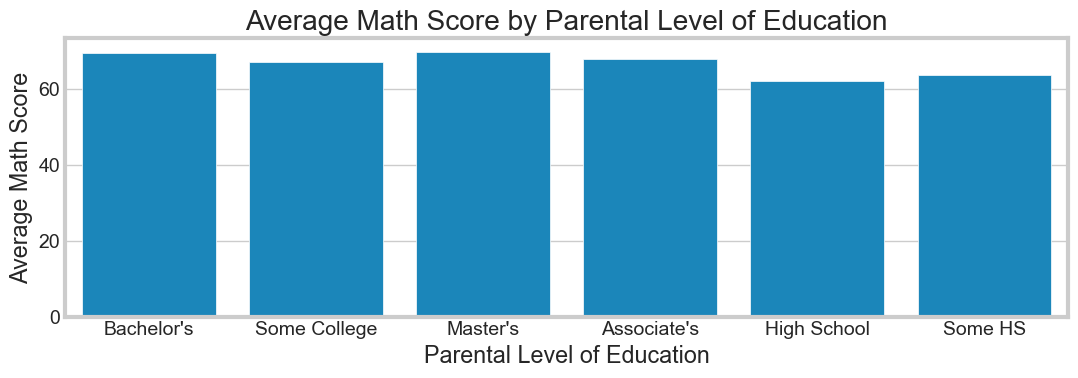

In [22]:
plt.figure(figsize=(11, 4))
sns.barplot(data=df, x="parental level of education", y="math score", estimator="mean", errorbar=None)

plt.title("Average Math Score by Parental Level of Education")
plt.xlabel("Parental Level of Education")
plt.ylabel("Average Math Score")

ticks = plt.xticks()[0]
plt.xticks(ticks, ["Bachelor's", "Some College", "Master's", "Associate's", "High School","Some HS"], rotation=0)

plt.tight_layout()
plt.show()

Math scores go up a little as parental education level increases, but the differences aren’t too big. There’s a small upward trend, so students with more educated parents tend to do slightly better overall.

# 5. Average Math Score By Race/Ethnicity 

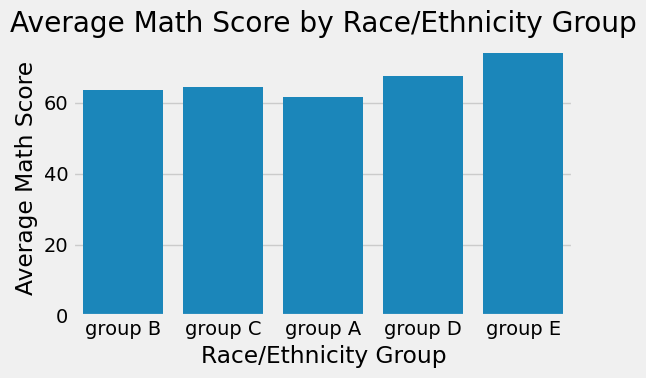

In [10]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="race/ethnicity", y="math score", estimator="mean", errorbar=None)

plt.title("Average Math Score by Race/Ethnicity Group")
plt.xlabel("Race/Ethnicity Group")
plt.ylabel("Average Math Score")
plt.tight_layout()
plt.show()

Some race/ethnicity groups have slightly higher average math scores than others, but the differences aren’t that big. There’s some variation, but it’s not as strong of a relationship as things like lunch type or test prep.

# 6. Correlation Heatmap of All Three Scores

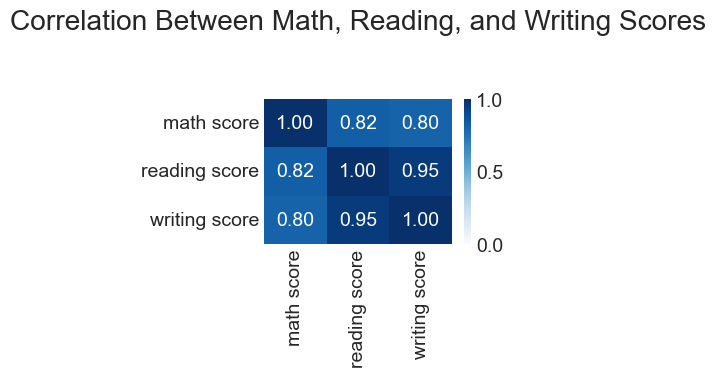

In [29]:
score_cols = ["math score", "reading score", "writing score"]
corr = df[score_cols].corr()

plt.figure(figsize=(4, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title("Correlation Between Math, Reading, and Writing Scores", pad=50)
plt.tight_layout()
plt.show()

All three subjects are really strongly connected, so students who do well in one usually do well in the others too. It basically shows that overall academic performance stays pretty consistent across subjects.

# Conclusion

Overall, the visualizations make it pretty clear that lunch type and test prep have the strongest impact on math scores. Students with standard lunch and those who completed the prep course almost always scored higher. Parental education and race/ethnicity show smaller differences, and gender seems to affect scores the least. The heatmap also shows that students who do well in one subject usually do well in the others. So overall, it looks like resources and preparation matter more for performance than the demographic factors in this dataset.